# 持久化与记忆

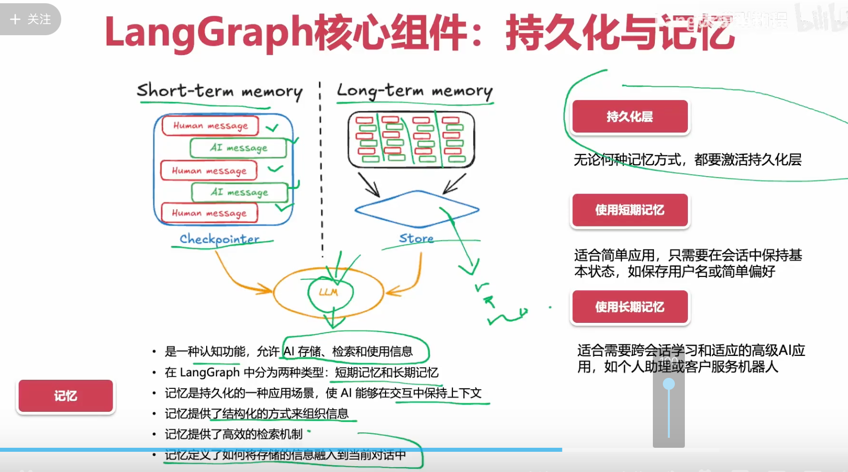
- 线程隔离持久化层
- 跨线程持久化调用
- 短期记忆的实现
- 长期记忆的实现
- 总结与优化技术

## 一、线程隔离的持久化层

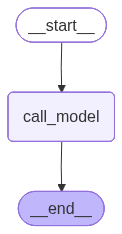

In [22]:
import uuid

from langchain_core.runnables import RunnableConfig

from model_factory import MiniMax_Model
import os
from langgraph.graph import StateGraph,MessagesState,START,END
from IPython.display import Image,display


def call_model(state:MessagesState):
    response = MiniMax_Model.invoke(state["messages"])
    return {
        "messages":response
    }

graph_builder = StateGraph(MessagesState)
graph_builder.add_node(call_model)
graph_builder.add_edge(START,"call_model")
graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

### 01.添加记忆(内存)

In [23]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)


### 02.会话测试

In [24]:
config = {
    "configurable": {
        "thread_id": "test_thread_1"
    }
}
input_messages = {
    "messages":[
        {
            "role":"user",
            "content":"my name is tom"
        }
    ]
}

for chunk in graph.stream(input=input_messages,stream_mode="values",config=config):
    chunk["messages"][-1].pretty_print()

config = {
    "configurable": {
        "thread_id": "test_thread_2"
    }
}
input_messages = {
    "messages":[
        {
            "role":"user",
            "content":"what is my name?"
        }
    ]
}
for chunk in graph.stream(input=input_messages,stream_mode="values",config=config):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

my name is tom
================================== Ai Message ==================================



Hello Tom! Nice to meet you. How can I help you today?
================================ Human Message =================================

what is my name?
================================== Ai Message ==================================



I don't know your name! You haven't told me yet. What would you like me to call you?


记忆的控制必须有
```python
config = {
    "configurable": {
        "thread_id": "test_thread_2"
    }
}
```
我们可以看test_thread_1的记忆与test_thread_2的记忆是隔离的,当然我们可以使用user_id,这样让同一个用户的不同thread共享记忆.

## 二、跨线程持久化记忆

## 01.使用内存存储向量话记忆

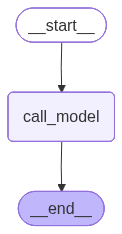

In [28]:
from langgraph.store.memory import InMemoryStore
from model_factory import embedding_model
from typing import Annotated
from langchain_core.runnables import  RunnableConfig
from langgraph.graph import  StateGraph,START,END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.base import BaseStore

in_memory_store = InMemoryStore(
    index={
        "embed":embedding_model,
    }
)

# 注意我们将store参数传递给了节点
def call_model(state:MessagesState,config:RunnableConfig,*,store:BaseStore):
    # 从存储中获得用户信息
    user_id = config["configurable"]["user_id"]

    namespace = ("memories",user_id)

    memories = store.search(namespace,query=str(state["messages"][-1].content))

    info = "\n".join([d.value["data"] for d in memories])
    system_msg = f"用户信息{info}"
    # 如果用户要求模型记住记忆,则存储记忆

    last_message = state["messages"][-1]
    if "记住" in last_message.content or "remember" in last_message.content.lower():
        # 硬编码一个记忆
        memory = "user's name is tom"
        store.put(namespace, str(uuid.uuid4()),{"data":memory})

    response =  MiniMax_Model.invoke(input=[
            {
                "role":"system",
                "content":system_msg
            },*state["messages"],
        ]
    )

    return {
        "messages":response
    }

graph_builder = StateGraph(MessagesState)
graph_builder.add_node(call_model)
graph_builder.add_edge(START,"call_model")
graph = graph_builder.compile(store=in_memory_store)
display(Image(graph.get_graph().draw_mermaid_png()))



### 调用测试

In [33]:
config = {
    "configurable":{
        "user_id":"user_1",
        "thread_id":"thread_1"
    }
}

input = {
    "messages":[
        {
            "role":"user",
            "content":"i hava a cat,remember"
        }
    ]
}

result = graph.stream(input=input,config=config,stream_mode="values")
for chunk in result:
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

i hava a cat,remember
================================== Ai Message ==================================



Got it! I'll remember that you have a cat 🐱

Is there anything cat-related I can help you with? Whether it's care tips, health questions, or just chatting about cats, I'm happy to help!


In [35]:
config = {
    "configurable":{
        "user_id":"user_1",
        "thread_id":"thread_2"
    }
}

input = {
    "messages":[
        {
            "role":"user",
            "content":"what is my name"
        }
    ]
}

result = graph.stream(input=input,config=config,stream_mode="values")
for chunk in result:
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

what is my name
================================== Ai Message ==================================



Your name is Tom!


### 直接查询内存中的记忆

In [37]:
for memory in in_memory_store.search(("memories","user_1")):
    print(memory.value)

{'data': "user's name is tom"}
